In [ ]:
!pip install catboost

In [ ]:
pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
import lightgbm as lgb
from catboost import CatBoostClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, Input

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("/content/ThemophilicProteinFV.csv")

X = df.drop(columns=['label'])
Y = df['label']

# Convert non-numeric → NaN → Drop
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
Y = Y.loc[X.index]

# =========================
# 3. NORMALIZATION
# =========================
X = X.to_numpy()
Y = Y.to_numpy()

scaler = MinMaxScaler().fit(X)
X = scaler.transform(X)
X = np.nan_to_num(X.astype('float32'))





In [ ]:
# =========================
# 4. t-SNE
# =========================
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, Y_train, Y_test = train_test_split(
    X_tsne, Y, test_size=0.2, random_state=42, stratify=Y
)

[LightGBM] [Info] Number of positive: 2002, number of negative: 2703
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 4705, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.425505 -> initscore=-0.300216
[LightGBM] [Info] Start training from score -0.300216


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14774/14774 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
14774/14774 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step


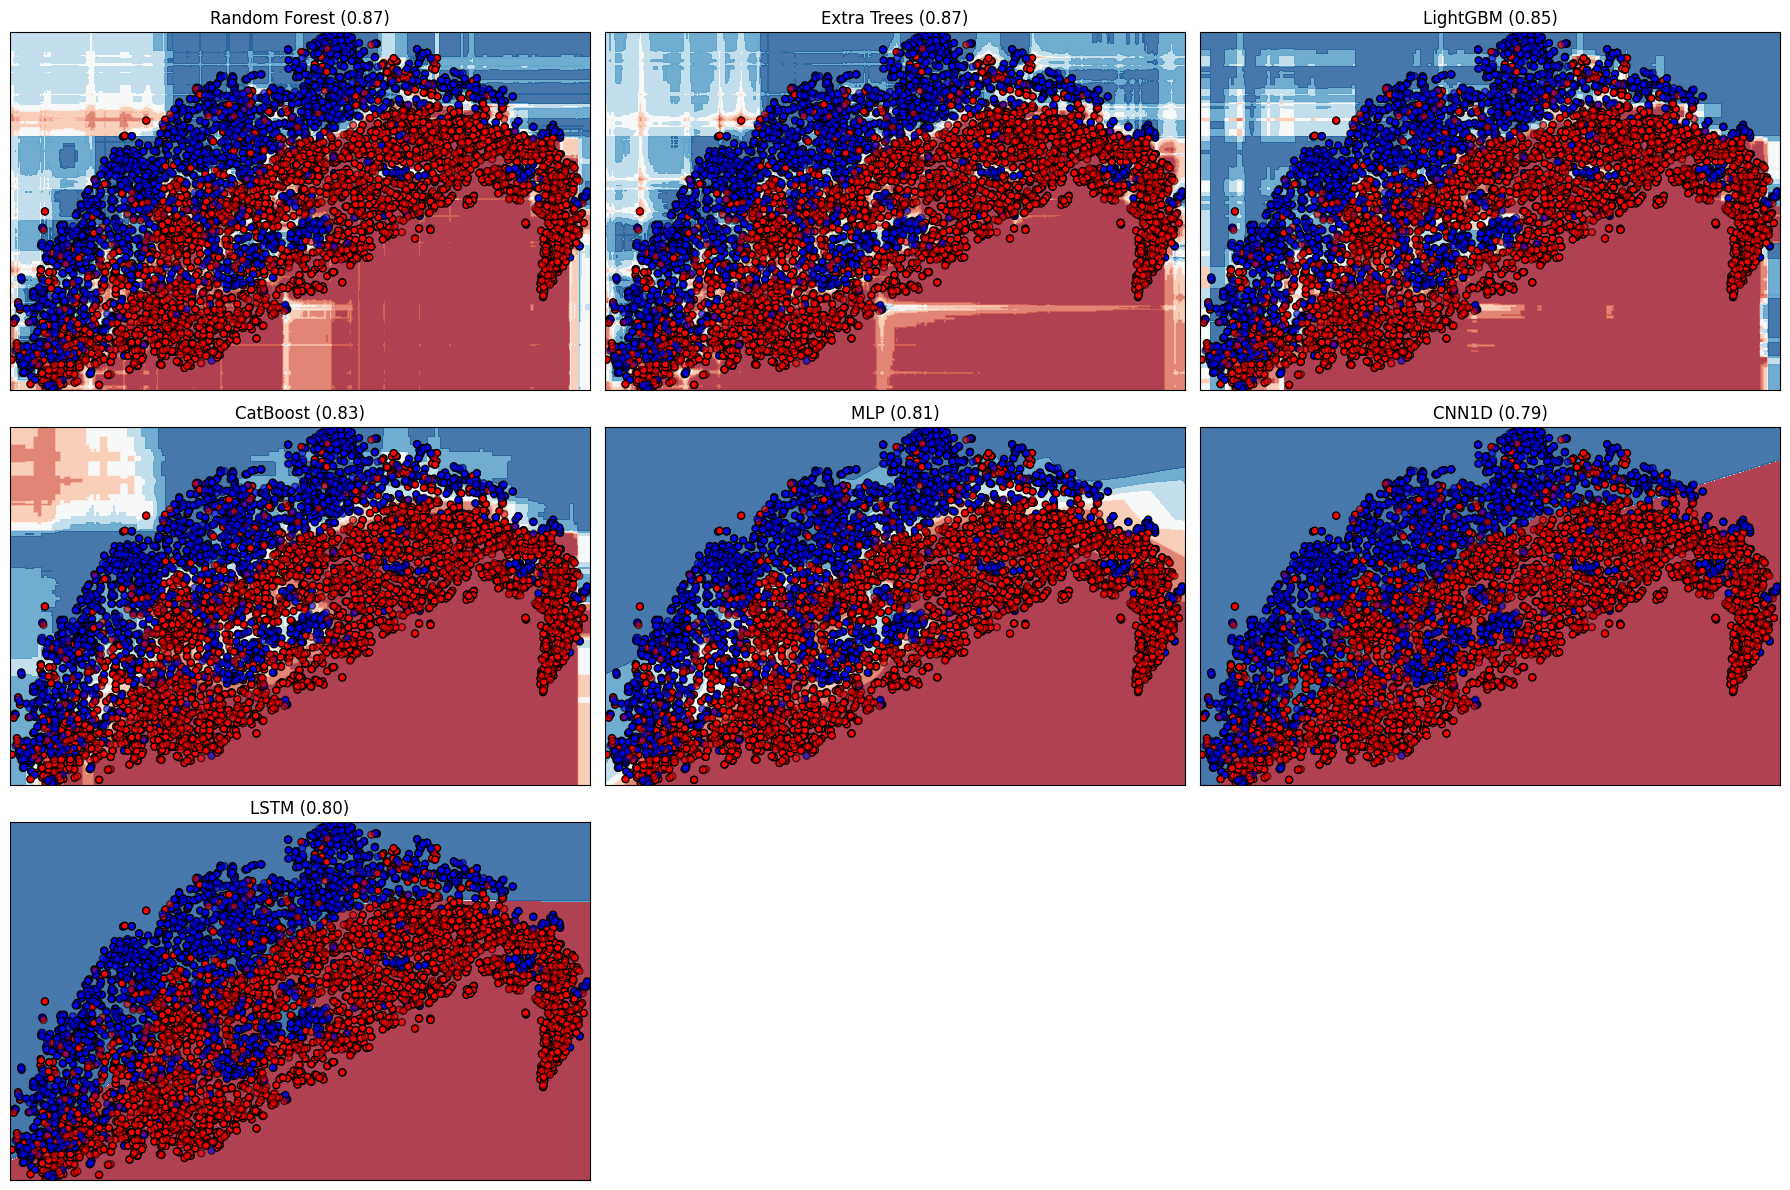

In [ ]:
# =========================
# 6. MODELS (ORDERED)
# =========================
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, iterations=100, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42),
}

# =========================
# 7. CNN MODEL
# =========================
cnn = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(32, kernel_size=2, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid")
])

cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn.fit(X_train.reshape(-1, X_train.shape[1], 1), Y_train, epochs=10, verbose=0)

# =========================
# 8. LSTM MODEL
# =========================
lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm.fit(X_train.reshape(-1, X_train.shape[1], 1), Y_train, epochs=10, verbose=0)

# Add DL models
classifiers["CNN1D"] = cnn
classifiers["LSTM"] = lstm

# =========================
# 9. DECISION BOUNDARY GRID
# =========================
h = 0.2
x_min, x_max = X_tsne[:, 0].min() - 0.5, X_tsne[:, 0].max() + 0.5
y_min, y_max = X_tsne[:, 1].min() - 0.5, X_tsne[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])

# =========================
# 10. PLOTTING
# =========================
figure = plt.figure(figsize=(18, 12))
i = 1

for name, clf in classifiers.items():
    ax = plt.subplot(3, 3, i)

    if name in ["CNN1D", "LSTM"]:
        X_test_r = X_test.reshape(-1, X_train.shape[1], 1)
        Y_pred = (clf.predict(X_test_r) > 0.5).astype(int).flatten()
        score = accuracy_score(Y_test, Y_pred)

        grid = np.c_[xx.ravel(), yy.ravel()]
        grid_r = grid.reshape(-1, X_train.shape[1], 1)
        Z = (clf.predict(grid_r) > 0.5).astype(int).flatten()

    else:
        clf.fit(X_train, Y_train)
        Y_pred = clf.predict(X_test)
        score = accuracy_score(Y_test, Y_pred)

        if hasattr(clf, "predict_proba"):
            Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        else:
            Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cm, alpha=0.8)

    # Scatter points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=Y_train,
               cmap=cm_bright, edgecolors="black", s=25)

    ax.scatter(X_test[:, 0], X_test[:, 1], c=Y_test,
               cmap=cm_bright, alpha=0.6, edgecolors="black", s=25)

    ax.set_title(f"{name} ({score:.2f})")
    ax.set_xticks(())
    ax.set_yticks(())

    i += 1

plt.tight_layout()
plt.show()